# Controlled Ridge Feature and Regularization Comparison

We compare the ridge baseline's feature blocks and L2 penalty using the same five game-grouped folds, stratified within week. The candidates are static context, dynamic defender movement, dynamic plus pass-rush pressure, and dynamic plus full pocket/QB context. Each is tested at L2 values 1, 5, 25, 100, and 500. All preprocessing and categorical levels are fit inside each training fold; penalties reuse the fold's cached unregularized normal equations.

We judge candidates on three separate questions: how well they predict held-out route separation change, whether expected values remain calibrated, and whether receiver residuals repeat across two disjoint sets of games. Route error is compared to the current reference (`dynamic_l2_25`) with a paired game-cluster bootstrap. Receiver reliability uses the same week-balanced game halves and 20-route minimum used in earlier experiments.

This is a model-selection comparison on the 2021 sample, not a final untouched test. The prior 2023 transfer check covers the common static/dynamic feature subsets, but does not contain all PFF and QB features needed to externally test every candidate here.

In [1]:
from pathlib import Path
import html
import math
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from IPython.display import HTML, SVG, display
from separation_over_expected.reports import read_csv_rows

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "ridge_comparison"
METRICS = read_csv_rows(OUTPUT_DIR / "candidate_metrics.csv")
FOLDS = read_csv_rows(OUTPUT_DIR / "fold_metrics.csv")
DECILES = read_csv_rows(OUTPUT_DIR / "calibration_deciles.csv")
PLAYER_HALVES = read_csv_rows(OUTPUT_DIR / "receiver_half_scores.csv")
RELIABILITY = read_csv_rows(OUTPUT_DIR / "receiver_reliability.csv")
PREDICTIONS = read_csv_rows(OUTPUT_DIR / "route_oof_predictions.csv")

len(PREDICTIONS), len(METRICS), len(FOLDS), len(DECILES), len(PLAYER_HALVES), len(RELIABILITY)

## Verify that this is a paired comparison

Every candidate scores every eligible WR route exactly once; each game stays within a single fold and the receiver-half assignment is shared. The baseline is `dynamic_l2_25`, matching the current preferred feature block and penalty.

In [1]:
from collections import Counter, defaultdict

route_keys = [(row["gameId"], row["playId"], row["nflId"]) for row in PREDICTIONS]
folds_by_game = defaultdict(set)
halves_by_game = defaultdict(set)
for row in PREDICTIONS:
    folds_by_game[(row["week"], row["gameId"])].add(row["fold"])
    halves_by_game[(row["week"], row["gameId"])].add(row["reliability_half"])

integrity = {
    "routes": len(PREDICTIONS),
    "unique routes": len(set(route_keys)),
    "games": len(folds_by_game),
    "games assigned to multiple folds": sum(len(value) != 1 for value in folds_by_game.values()),
    "games assigned to multiple receiver halves": sum(len(value) != 1 for value in halves_by_game.values()),
    "fold counts": dict(sorted(Counter(row["fold"] for row in PREDICTIONS).items())),
}
assert integrity["routes"] == integrity["unique routes"]
assert integrity["games assigned to multiple folds"] == 0
assert integrity["games assigned to multiple receiver halves"] == 0
integrity

## Route prediction across penalties and feature sets

Each point is aggregate out-of-fold RMSE; vertical bars show the standard deviation of the five fold RMSEs. The x-axis is logarithmic because the candidate penalties span three orders of magnitude. Paired game-bootstrap intervals for change from `dynamic_l2_25` are in the results table below.

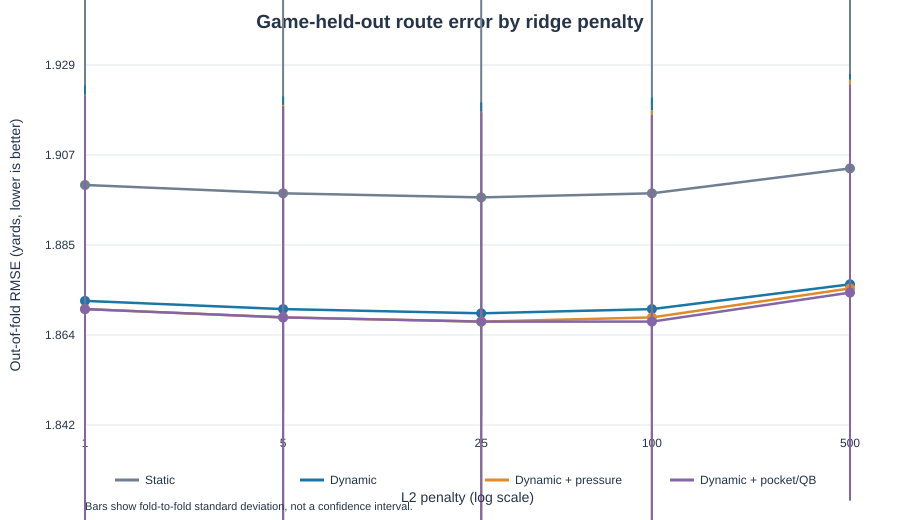

In [1]:
FEATURE_LABELS = {
    "static": "Static",
    "dynamic": "Dynamic",
    "dynamic_pressure": "Dynamic + pressure",
    "dynamic_pocket": "Dynamic + pocket/QB",
}
COLORS = {
    "static": "#6f7f8f",
    "dynamic": "#1976a5",
    "dynamic_pressure": "#e08a28",
    "dynamic_pocket": "#8466a8",
}


def rmse_plot_svg(metrics, folds, width=900, height=520):
    left, right, top, bottom = 85, 850, 65, 425
    values = [float(row["rmse"]) for row in metrics]
    low, high = min(values) - 0.025, max(values) + 0.025
    x0, x1 = math.log10(1), math.log10(500)
    x_pos = lambda value: left + (math.log10(float(value)) - x0) / (x1 - x0) * (right - left)
    y_pos = lambda value: bottom - (float(value) - low) / (high - low) * (bottom - top)
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<style>text{font-family:Arial,sans-serif;fill:#253449}.grid{stroke:#e2e8ee}</style>',
        f'<text x="{width/2}" y="28" text-anchor="middle" font-size="19" font-weight="bold">Game-held-out route error by ridge penalty</text>',
    ]
    for tick in range(5):
        value = low + (high - low) * tick / 4
        y = y_pos(value)
        parts.extend([
            f'<line class="grid" x1="{left}" y1="{y:.1f}" x2="{right}" y2="{y:.1f}"/>',
            f'<text x="{left-10}" y="{y+4:.1f}" text-anchor="end" font-size="12">{value:.3f}</text>',
        ])
    for tick in (1, 5, 25, 100, 500):
        x = x_pos(tick)
        parts.extend([
            f'<line class="grid" x1="{x:.1f}" y1="{top}" x2="{x:.1f}" y2="{bottom}"/>',
            f'<text x="{x:.1f}" y="{bottom+22}" text-anchor="middle" font-size="12">{tick}</text>',
        ])
    for feature, label in FEATURE_LABELS.items():
        rows = sorted((row for row in metrics if row["feature_set"] == feature), key=lambda row: float(row["l2"]))
        coords = []
        for row in rows:
            penalty = float(row["l2"])
            x, y = x_pos(penalty), y_pos(row["rmse"])
            matching_folds = [float(item["rmse"]) for item in folds if item["candidate"] == row["candidate"]]
            sd = statistics.stdev(matching_folds) if len(matching_folds) > 1 else 0.0
            y_low, y_high = y_pos(float(row["rmse"]) - sd), y_pos(float(row["rmse"]) + sd)
            coords.append(f"{x:.1f},{y:.1f}")
            title = html.escape(f'{label}, L2={penalty:g}: RMSE {float(row["rmse"]):.3f} +/- {sd:.3f} fold SD')
            parts.append(
                f'<line x1="{x:.1f}" y1="{y_low:.1f}" x2="{x:.1f}" y2="{y_high:.1f}" stroke="{COLORS[feature]}" stroke-width="2"/><circle cx="{x:.1f}" cy="{y:.1f}" r="5" fill="{COLORS[feature]}"><title>{title}</title></circle>'
            )
        parts.append(f'<polyline points="{" ".join(coords)}" fill="none" stroke="{COLORS[feature]}" stroke-width="2.5"/>')
    for index, (feature, label) in enumerate(FEATURE_LABELS.items()):
        x = 115 + index * 185
        parts.append(f'<line x1="{x}" y1="480" x2="{x+24}" y2="480" stroke="{COLORS[feature]}" stroke-width="3"/><text x="{x+30}" y="484" font-size="12">{label}</text>')
    parts.extend([
        f'<text x="{(left+right)/2}" y="{height-18}" text-anchor="middle" font-size="14">L2 penalty (log scale)</text>',
        f'<text x="20" y="{(top+bottom)/2}" text-anchor="middle" font-size="14" transform="rotate(-90 20 {(top+bottom)/2})">Out-of-fold RMSE (yards, lower is better)</text>',
        '<text x="85" y="510" font-size="11" fill="#58697a">Bars show fold-to-fold standard deviation, not a confidence interval.</text>',
        '</svg>',
    ])
    return "".join(parts)


import statistics
display(SVG(rmse_plot_svg(METRICS, FOLDS)))

## Receiver reliability across feature and penalty choices

Pearson agreement measures repeatability in receiver residual levels; Spearman measures repeatability of rank order. Points show the split-half correlation and bars show receiver-bootstrap 95% intervals. The paired difference columns compare each candidate with `dynamic_l2_25` on the same eligible receivers.

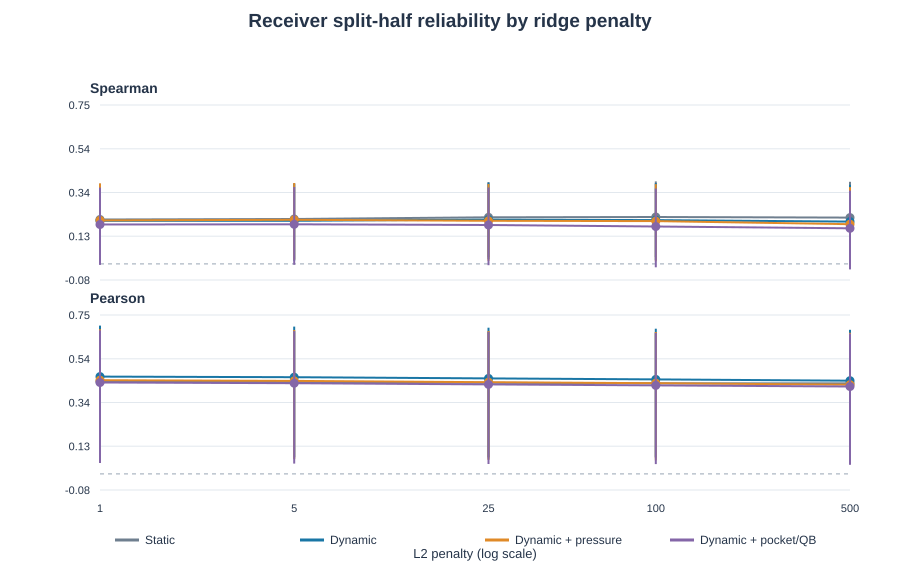

In [1]:
def reliability_plot_svg(rows, width=900, height=570):
    left, right, top, bottom = 100, 850, 65, 490
    lower = min(float(row[f"{name}_ci_lower"]) for row in rows for name in ("pearson", "spearman"))
    upper = max(float(row[f"{name}_ci_upper"]) for row in rows for name in ("pearson", "spearman"))
    low, high = max(-1.0, lower - 0.05), min(1.0, upper + 0.05)
    x0, x1 = math.log10(1), math.log10(500)
    x_pos = lambda value: left + (math.log10(float(value)) - x0) / (x1 - x0) * (right - left)
    y_pos = lambda value, panel: (bottom if panel == 0 else 280) - (float(value) - low) / (high - low) * 175
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<style>text{font-family:Arial,sans-serif;fill:#253449}.grid{stroke:#e2e8ee}</style>',
        f'<text x="{width/2}" y="27" text-anchor="middle" font-size="19" font-weight="bold">Receiver split-half reliability by ridge penalty</text>',
    ]
    for panel, statistic in enumerate(("pearson", "spearman")):
        panel_bottom = bottom if panel == 0 else 280
        panel_top = panel_bottom - 175
        parts.append(f'<text x="{left-10}" y="{panel_top-12}" font-size="14" font-weight="bold">{statistic.title()}</text>')
        for tick in range(5):
            value = low + (high - low) * tick / 4
            y = y_pos(value, panel)
            parts.extend([
                f'<line class="grid" x1="{left}" y1="{y:.1f}" x2="{right}" y2="{y:.1f}"/>',
                f'<text x="{left-10}" y="{y+4:.1f}" text-anchor="end" font-size="11">{value:.2f}</text>',
            ])
        zero = y_pos(0, panel)
        parts.append(f'<line x1="{left}" y1="{zero:.1f}" x2="{right}" y2="{zero:.1f}" stroke="#98a6b5" stroke-dasharray="4 4"/>')
        for feature, label in FEATURE_LABELS.items():
            selected = sorted((row for row in rows if row["feature_set"] == feature), key=lambda row: float(row["l2"]))
            coords = []
            for row in selected:
                x = x_pos(row["l2"])
                value = float(row[statistic])
                y = y_pos(value, panel)
                lower_ci, upper_ci = float(row[f"{statistic}_ci_lower"]), float(row[f"{statistic}_ci_upper"])
                parts.append(
                    f'<line x1="{x:.1f}" y1="{y_pos(lower_ci,panel):.1f}" x2="{x:.1f}" y2="{y_pos(upper_ci,panel):.1f}" stroke="{COLORS[feature]}" stroke-width="2"/><circle cx="{x:.1f}" cy="{y:.1f}" r="4.5" fill="{COLORS[feature]}"><title>{label} L2={row["l2"]}: {statistic}={value:.3f}, 95% CI [{lower_ci:.3f}, {upper_ci:.3f}]</title></circle>'
                )
                coords.append(f"{x:.1f},{y:.1f}")
            parts.append(f'<polyline points="{" ".join(coords)}" fill="none" stroke="{COLORS[feature]}" stroke-width="2"/>')
    for tick in (1, 5, 25, 100, 500):
        x = x_pos(tick)
        parts.append(f'<text x="{x:.1f}" y="{bottom+22}" text-anchor="middle" font-size="11">{tick}</text>')
    for index, (feature, label) in enumerate(FEATURE_LABELS.items()):
        x = 115 + index * 185
        parts.append(f'<line x1="{x}" y1="540" x2="{x+24}" y2="540" stroke="{COLORS[feature]}" stroke-width="3"/><text x="{x+30}" y="544" font-size="12">{label}</text>')
    parts.extend([
        f'<text x="{(left+right)/2}" y="{height-12}" text-anchor="middle" font-size="13">L2 penalty (log scale)</text>',
        '</svg>',
    ])
    return "".join(parts)


display(SVG(reliability_plot_svg(RELIABILITY)))

## Calibration curves for the reference and leading candidates

A candidate is only useful if its expected separation change remains interpretable. These decile curves compare out-of-fold mean observed change against mean predicted change. The diagonal is ideal calibration. We show the current reference, the lowest-RMSE candidate, and the strongest Pearson split-half candidate; names may overlap if the same candidate wins more than one criterion.

In [1]:
best_rmse = min(METRICS, key=lambda row: float(row["rmse"]))
best_reliability = max(RELIABILITY, key=lambda row: float(row["pearson"]))
selected_candidates = list(dict.fromkeys((
    "dynamic_l2_25",
    best_rmse["candidate"],
    best_reliability["candidate"],
)))
selected_candidates

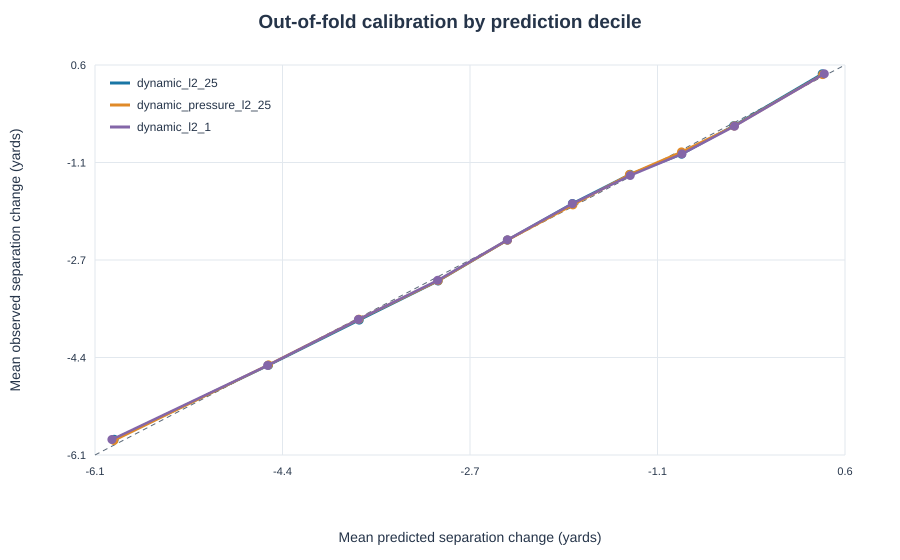

In [1]:
def calibration_plot_svg(deciles, selected, width=900, height=560):
    left, right, top, bottom = 95, 845, 65, 455
    chosen = [row for row in deciles if row["candidate"] in selected]
    values = [float(row[key]) for row in chosen for key in ("mean_predicted", "mean_actual")]
    low, high = min(values) - 0.15, max(values) + 0.15
    x_pos = lambda value: left + (float(value) - low) / (high - low) * (right - left)
    y_pos = lambda value: bottom - (float(value) - low) / (high - low) * (bottom - top)
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<style>text{font-family:Arial,sans-serif;fill:#253449}.grid{stroke:#e2e8ee}</style>',
        f'<text x="{width/2}" y="28" text-anchor="middle" font-size="19" font-weight="bold">Out-of-fold calibration by prediction decile</text>',
    ]
    for tick in range(5):
        value = low + (high - low) * tick / 4
        x, y = x_pos(value), y_pos(value)
        parts.extend([
            f'<line class="grid" x1="{x:.1f}" y1="{top}" x2="{x:.1f}" y2="{bottom}"/>',
            f'<line class="grid" x1="{left}" y1="{y:.1f}" x2="{right}" y2="{y:.1f}"/>',
            f'<text x="{x:.1f}" y="{bottom+20}" text-anchor="middle" font-size="11">{value:.1f}</text>',
            f'<text x="{left-9}" y="{y+4:.1f}" text-anchor="end" font-size="11">{value:.1f}</text>',
        ])
    parts.append(f'<line x1="{x_pos(low):.1f}" y1="{y_pos(low):.1f}" x2="{x_pos(high):.1f}" y2="{y_pos(high):.1f}" stroke="#596878" stroke-dasharray="5 4"/>')
    palette = ("#1976a5", "#e08a28", "#8466a8")
    for i, candidate in enumerate(selected):
        rows = sorted((row for row in deciles if row["candidate"] == candidate), key=lambda row: int(row["decile"]))
        coords = []
        for row in rows:
            x, y = x_pos(row["mean_predicted"]), y_pos(row["mean_actual"])
            coords.append(f"{x:.1f},{y:.1f}")
            parts.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="4.5" fill="{palette[i]}"><title>{candidate}, decile {row["decile"]}: observed {float(row["mean_actual"]):.3f}, predicted {float(row["mean_predicted"]):.3f}</title></circle>')
        parts.append(f'<polyline points="{" ".join(coords)}" fill="none" stroke="{palette[i]}" stroke-width="2.5"/>')
        parts.append(f'<line x1="{left+15}" y1="{top+18+i*22}" x2="{left+35}" y2="{top+18+i*22}" stroke="{palette[i]}" stroke-width="3"/><text x="{left+42}" y="{top+22+i*22}" font-size="12">{html.escape(candidate)}</text>')
    parts.extend([
        f'<text x="{(left+right)/2}" y="{height-18}" text-anchor="middle" font-size="14">Mean predicted separation change (yards)</text>',
        f'<text x="20" y="{(top+bottom)/2}" text-anchor="middle" font-size="14" transform="rotate(-90 20 {(top+bottom)/2})">Mean observed separation change (yards)</text>',
        '</svg>',
    ])
    return "".join(parts)


display(SVG(calibration_plot_svg(DECILES, selected_candidates)))

## Compare candidates without collapsing the objectives

The RMSE bootstrap is paired by game against `dynamic_l2_25`; negative change favors the candidate. Receiver intervals are also paired against that same reference. Look for a candidate that improves route error without losing calibration or receiver repeatability. The lowest RMSE alone is not automatically the winner, especially when the paired interval includes zero or receiver reliability drops.

In [1]:
def html_table(rows, columns):
    heads = "".join(
        f'<th style="padding:5px 8px;text-align:left;border-bottom:2px solid #ccd5de">{html.escape(label)}</th>'
        for label, _ in columns
    )
    body = "".join(
        "<tr>" + "".join(
            f'<td style="padding:4px 8px;border-bottom:1px solid #e4e9ef">{html.escape(str(row[key]))}</td>'
            for _, key in columns
        ) + "</tr>"
        for row in rows
    )
    return HTML(f"<table style='border-collapse:collapse'>{heads and '<thead><tr>'+heads+'</tr></thead>'}<tbody>{body}</tbody></table>")


metrics_by_name = {row["candidate"]: row for row in METRICS}
reliability_by_name = {row["candidate"]: row for row in RELIABILITY}
route_leaders = sorted(METRICS, key=lambda row: float(row["rmse"]))[:10]
html_table(
    [
        {
            **row,
            "receiver_pearson": reliability_by_name[row["candidate"]]["pearson"],
            "receiver_pearson_delta": reliability_by_name[row["candidate"]]["pearson_delta_vs_dynamic_l2_25"],
        }
        for row in route_leaders
    ],
    [
        ("Candidate", "candidate"),
        ("RMSE", "rmse"),
        ("Δ RMSE vs reference [95% CI]", "rmse_delta_vs_dynamic_l2_25"),
        ("R²", "r2"),
        ("Calibration slope", "calibration_slope"),
        ("Mean abs decile bias", "mean_absolute_decile_bias"),
        ("Pearson reliability", "receiver_pearson"),
        ("Pearson gain vs reference", "receiver_pearson_delta"),
    ],
)

Candidate,RMSE,Δ RMSE vs reference [95% CI],R²,Calibration slope,Mean abs decile bias,Pearson reliability,Pearson gain vs reference
dynamic_pressure_l2_25,1.867,-0.00167993,0.509,0.99709117,0.03791236,0.434050,-0.017807
dynamic_pocket_l2_25,1.867,-0.00210783,0.509,0.99683116,0.04665890,0.423567,-0.028290
dynamic_pocket_l2_100,1.867,-0.00145567,0.509,1.00342672,0.04857592,0.418847,-0.033010
dynamic_pressure_l2_5,1.868,-0.00073028,0.508,0.99318829,0.03251031,0.439876,-0.011981
dynamic_pressure_l2_100,1.868,-0.00095529,0.508,1.00366382,0.04130218,0.428943,-0.022914
dynamic_pocket_l2_5,1.868,-0.00110064,0.509,0.99292859,0.04838459,0.429207,-0.022650
dynamic_l2_25,1.869,0.00000000,0.508,0.99715629,0.05065318,0.451857,0.000000
dynamic_l2_5,1.870,0.00100540,0.507,0.99318926,0.04845794,0.457384,0.005527
dynamic_l2_100,1.870,0.00065247,0.508,1.00377455,0.05220805,0.447225,-0.004632
dynamic_pressure_l2_1,1.870,0.00124754,0.507,0.99040822,0.03140047,0.443369,-0.008488


In [1]:
html_table(
    [
        {
            **row,
            "rmse": metrics_by_name[row["candidate"]]["rmse"],
            "rmse_delta": metrics_by_name[row["candidate"]]["rmse_delta_vs_dynamic_l2_25"],
        }
        for row in sorted(RELIABILITY, key=lambda row: float(row["pearson"]), reverse=True)[:10]
    ],
    [
        ("Candidate", "candidate"),
        ("Pearson", "pearson"),
        ("95% interval", "pearson_ci_lower"),
        ("Pearson gain vs reference", "pearson_delta_vs_dynamic_l2_25"),
        ("Gain 95% lower", "pearson_delta_lower_95"),
        ("Gain 95% upper", "pearson_delta_upper_95"),
        ("RMSE", "rmse"),
        ("RMSE gain vs reference", "rmse_delta"),
    ],
)

Candidate,Pearson,95% interval,Pearson gain vs reference,Gain 95% lower,Gain 95% upper,RMSE,RMSE gain vs reference
dynamic_l2_1,0.460557,0.079308,0.008700,-0.012880,0.032689,1.872,0.00301666
dynamic_l2_5,0.457384,0.079987,0.005527,-0.009261,0.020939,1.870,0.00100540
dynamic_l2_25,0.451857,0.079452,0.000000,0.000000,0.000000,1.869,0.00000000
dynamic_l2_100,0.447225,0.080542,-0.004632,-0.015505,0.008299,1.870,0.00065247
dynamic_pressure_l2_1,0.443369,0.070550,-0.008488,-0.036465,0.019218,1.870,0.00124754
dynamic_l2_500,0.440953,0.074422,-0.010904,-0.032201,0.012979,1.876,0.00714592
dynamic_pressure_l2_5,0.439876,0.069512,-0.011981,-0.033956,0.009436,1.868,-0.00073028
static_l2_1,0.436563,0.073027,-0.015294,-0.058729,0.041889,1.900,0.03120485
static_l2_5,0.434763,0.072859,-0.017094,-0.056349,0.035831,1.898,0.02917782
dynamic_pressure_l2_25,0.434050,0.065690,-0.017807,-0.034871,0.005132,1.867,-0.00167993


## Interpretation

Dynamic context is a clear improvement over static context: at L2=25, RMSE falls from about 1.897 to 1.869 yards, with the paired game-bootstrap interval excluding zero. Increasing regularization to L2=500 degrades route error across feature sets, while penalties from 5 to 100 are close. The calibration slopes stay near 1 throughout.

Pressure and full pocket/QB context produce the lowest route RMSE at L2=25, but their gains over dynamic L2=25 are only about 0.002 yards. Pressure improves RMSE by 0.0017 yards (paired 95% interval about -0.0029 to -0.0005); its receiver Pearson reliability is 0.434 versus 0.452 for the reference, and the paired interval for that drop includes zero. Full pocket/QB context lowers RMSE by about 0.0021 yards, but receiver Pearson falls to 0.424 and the paired reliability interval indicates a decrease. These tiny route-error gains do not establish a better receiver-level metric.

Keep dynamic L2=25 as the current reference model. The pressure model at L2=25 is a useful challenger for future validation, but these results do not justify replacing the reference. This is model selection on five game-held-out folds from one season; the winning candidates need validation on a separate season before any final selection.

Because all candidates are compared on the same 2021 cross-validation sample, the best observed candidate is still a selected CV result. The external 2023 check can confirm only the static and dynamic common-feature candidates. Any broader final model still needs future-season validation before being presented as a stable receiver evaluation.